<a href="https://colab.research.google.com/github/ASachoTanzer/CUSLIAttitudeControl/blob/main/AirCoreMagnetorquers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
# import itertools
# from tqdm import tqdm
from tqdm.contrib.itertools import product

In [ ]:
def coil(area, wire_length, num_coils, thickness, current, resistivity, density):
  # all inputs in SI units
	magnetic_moment  = num_coils*current*area
	resistance = resistivity*wire_length/(np.pi/4*thickness**2)
	power_consumption = current**2*resistance
	mass =	 wire_length*(np.pi/4*thickness**2)* density
	volume = area*num_coils*thickness
	length = num_coils*thickness
	power_efficiency = magnetic_moment/power_consumption
	current_efficiency = magnetic_moment/current
	mass_efficiency = magnetic_moment/mass
	return magnetic_moment, resistance, power_consumption, mass, volume, length, power_efficiency, current_efficiency, mass_efficiency


In [ ]:
# square coils:
def square(side_length, num_coils):
  area = side_length**2
  wire_length = side_length*4*num_coils
  return area, wire_length
# circular coils:
def circular(diameter, num_coils):
  area = np.pi/4*diameter**2
  wire_length = diameter*np.pi*num_coils
  return area, wire_length

def circular_thickness(diameter, num_coils, wire_thickness):
  diameter += wire_thickness/2
  area = np.pi/4*diameter**2
  wire_length = diameter*np.pi*num_coils
  return area, wire_length

In [ ]:
# Constants:
current = 1.2  # A
resistivity = 16.78e-9  # ohm*meter, from wikipedia at 20 degrees C. This decreases at lower temperatures, so power consumption should only decrease. Need to check that our temperature won't go above 20C (ie in direct sunlight)
density = 8935  # kg/m^3, from wikipedia at 20 degrees C

In [ ]:
num_coils = 84
diameter = 0.03  # m
thickness = 0.0008  # m
magnetic_moment, resistance, power_consumption, mass, volume, length, power_efficiency, current_efficiency, mass_efficiency = coil(*circular_thickness(diameter, num_coils, thickness), num_coils, thickness, current, resistivity, density)

print(f"Magnetic Moment: {magnetic_moment} Am^2")
print(f"Resistance: {resistance} Ohm")
print(f"Power Consumption: {power_consumption} W")
print(f"Mass: {mass} kg")
print(f"Volume: {volume} m^3")
print(f"Length: {length} m")
print(f"Power Efficiency: {power_efficiency} Am^2/W")
print(f"Current Efficiency: {current_efficiency} Am^2/A")
print(f"Mass Efficiency: {mass_efficiency} Am^2/kg")

Magnetic Moment: 0.07316402352188689 Am^2
Resistance: 0.2678088 Ohm
Power Consumption: 0.385644672 W
Mass: 0.0360302399633097 kg
Volume: 4.877601568125793e-05 m^3
Length: 0.06720000000000001 m
Power Efficiency: 0.1897187458663681 Am^2/W
Current Efficiency: 0.06097001960157241 Am^2/A
Mass Efficiency: 2.0306282610493644 Am^2/kg


In [ ]:
def coil_testing(area, num_coils, current, spool_length):
  # all inputs in SI units
  magnetic_moment  = num_coils*current*area
  edge_field_from_moment_1 = 1e-7*(3*(spool_length/2)**2*magnetic_moment/(spool_length/2)**5-magnetic_moment/(spool_length/2)**3)
  edge_field_from_moment_2 = 1e-7*2*magnetic_moment/(spool_length/2)**3
  edge_field_theoretical = 4*np.pi*1e-7*num_coils*current/(spool_length)/2
  center_field_theoretical = 4*np.pi*1e-7*num_coils*current/(spool_length)
  return magnetic_moment, edge_field_from_moment_1, edge_field_from_moment_2, edge_field_theoretical, center_field_theoretical


In [ ]:
num_coils = 84
diameter = 0.03  # m
current = 0.9  # A
spool_length = 0.094  # m
coil_testing(circular_thickness(diameter, num_coils, thickness)[0], num_coils, current, spool_length)

(0.054873017641415174,
 0.00010570493559503224,
 0.00010570493559503226,
 0.0005053285204497625,
 0.001010657040899525)

In [ ]:
def meets_constraints(dipole_f, dipole_l, mass_f, mass_l, length_f, length_l, diameter_f, diameter_l, power_f, power_l):
  if dipole_f < 0.06 or dipole_l < 0.06:
    return False
  if mass_f + 2* mass_l > 0.2:
    return False
  if (length_l > 0.09 or diameter_l > 0.03) or (length_f > 0.03 or diameter_f > 0.09):
    return False
  if (power_l*2+power_f)*2 > 20:
    return False
  return True

In [ ]:
# Grid search:
# variables: num_coils_flat, diameter_flat, num_coils_long, diameter_long, thickness
num_coils_flat = np.linspace(1, 50, dtype=int, num=20)
side_length_flat = np.linspace(0.04, 0.09, num=20)
num_coils_long = np.linspace(1, 200, dtype=int, num=20)
diameter_long = np.linspace(0.005, 0.03, num=20)
thickness = np.linspace(0.0001, 0.003, num=20)

working_combos = []

samples = product(num_coils_flat, side_length_flat, num_coils_long, diameter_long, thickness)
for (n_f, d_f, n_l, d_l, t) in samples:
  magnetic_moment_l, resistance_l, power_consumption_l, mass_l, volume_l, length_l, power_efficiency_l, current_efficiency_l, mass_efficiency_l = coil(*circular(d_l, n_l), n_l, t, current, resistivity, density)
  magnetic_moment_f, resistance_f, power_consumption_f, mass_f, volume_f, length_f, power_efficiency_f, current_efficiency_f, mass_efficiency_f = coil(*square(d_f, n_f), n_f, t, current, resistivity, density)
  if meets_constraints(magnetic_moment_f, magnetic_moment_l, mass_f, mass_l, length_f, length_l, d_f, d_l, power_consumption_f, power_consumption_l):
    working_combos.append([n_f, d_f, n_l, d_l, t])



  0%|          | 0/3200000 [00:00<?, ?it/s]

In [ ]:
len(working_combos)

28501

In [ ]:
working_combos[0]

[np.int64(11),
 np.float64(0.07947368421052631),
 np.int64(95),
 np.float64(0.03),
 np.float64(0.0002526315789473684)]

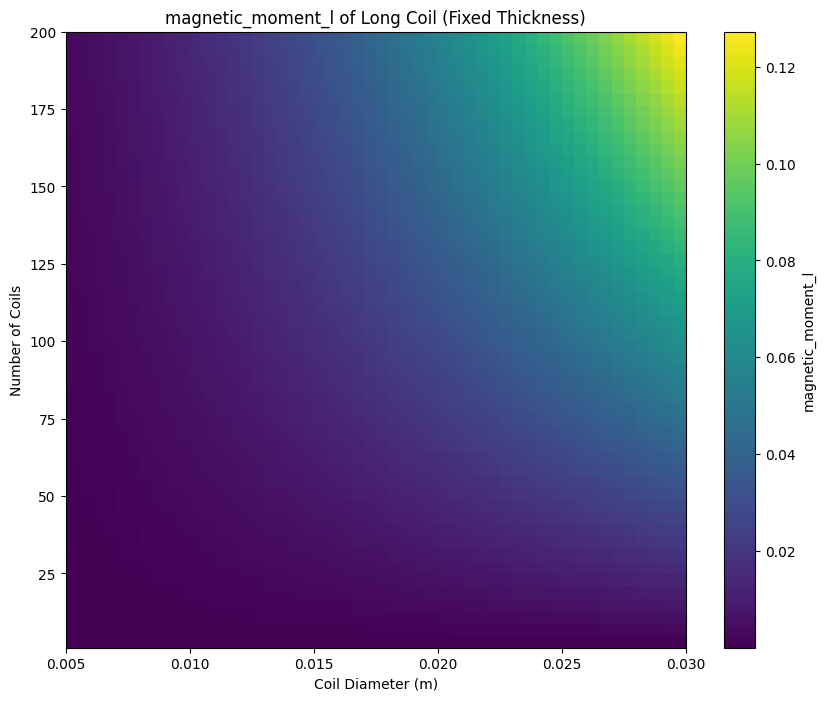

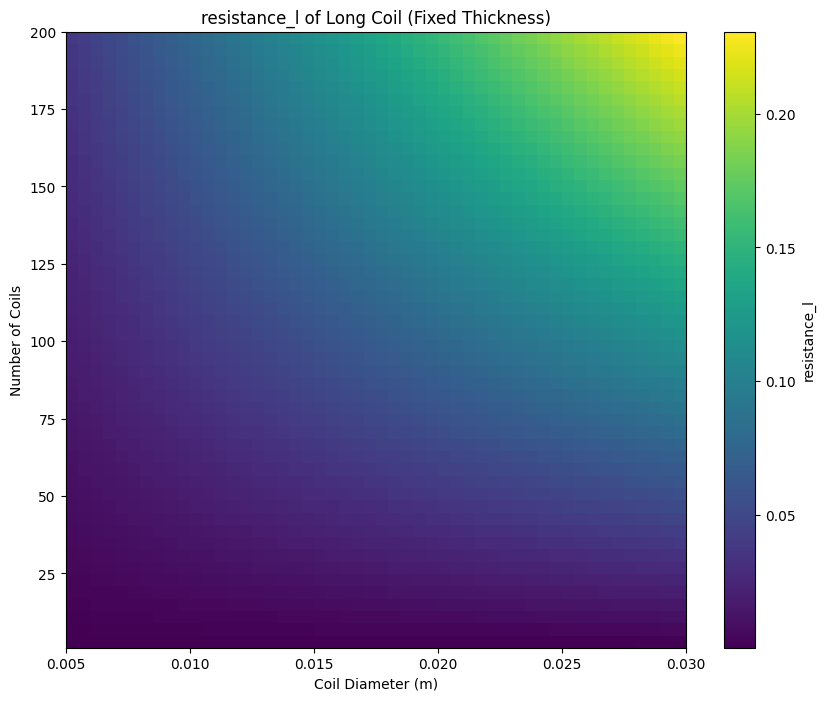

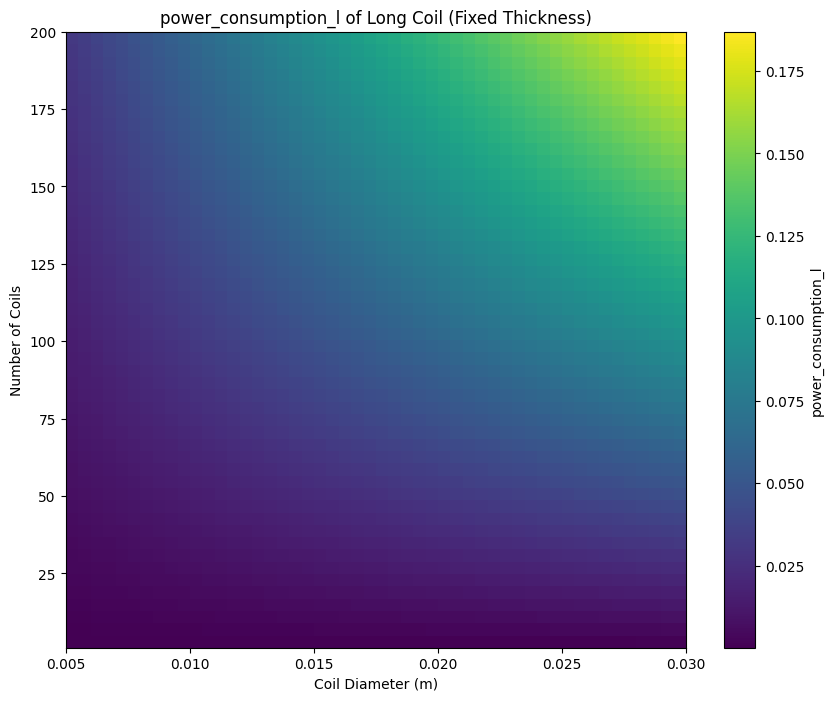

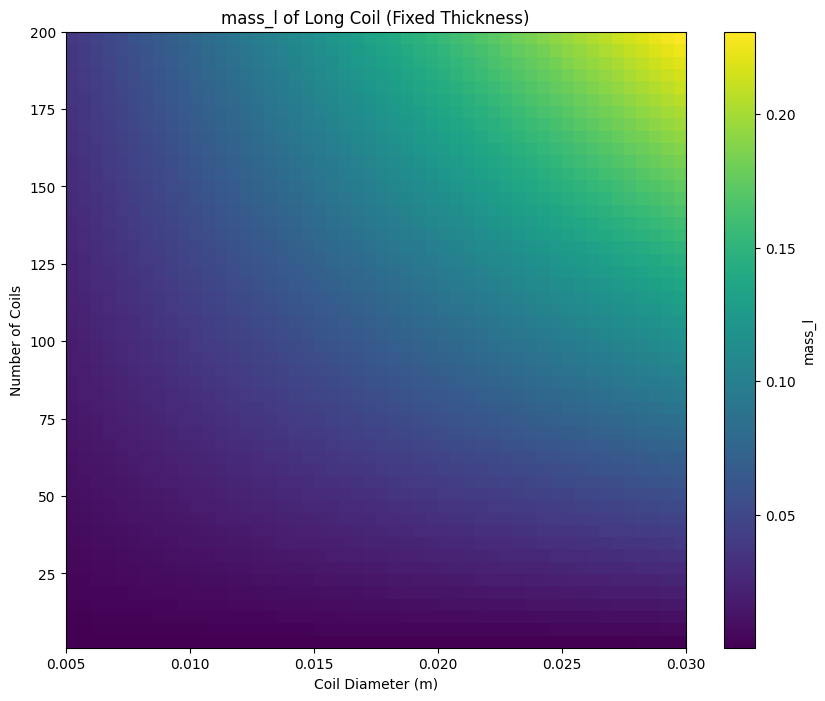

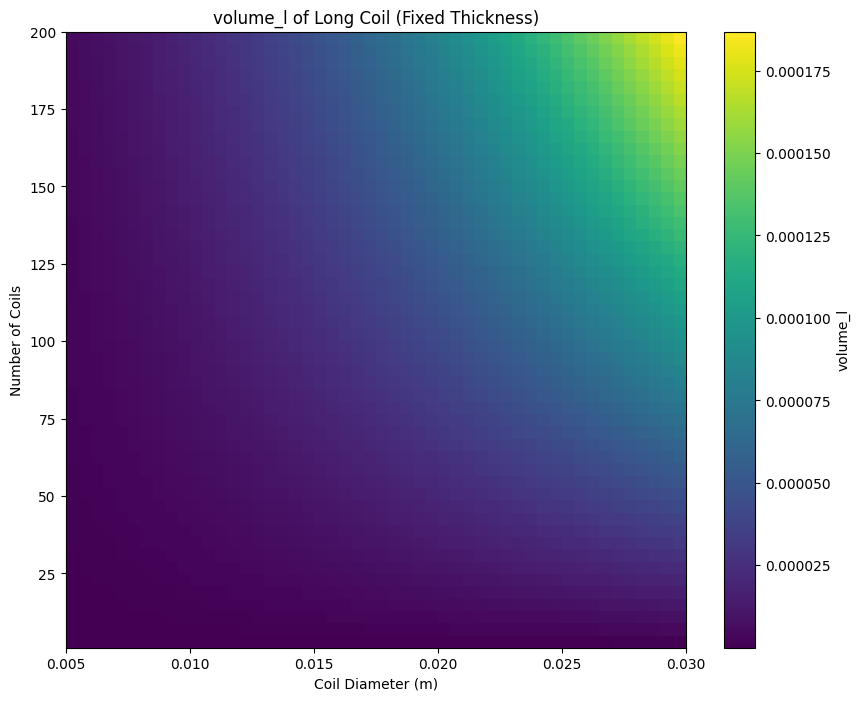

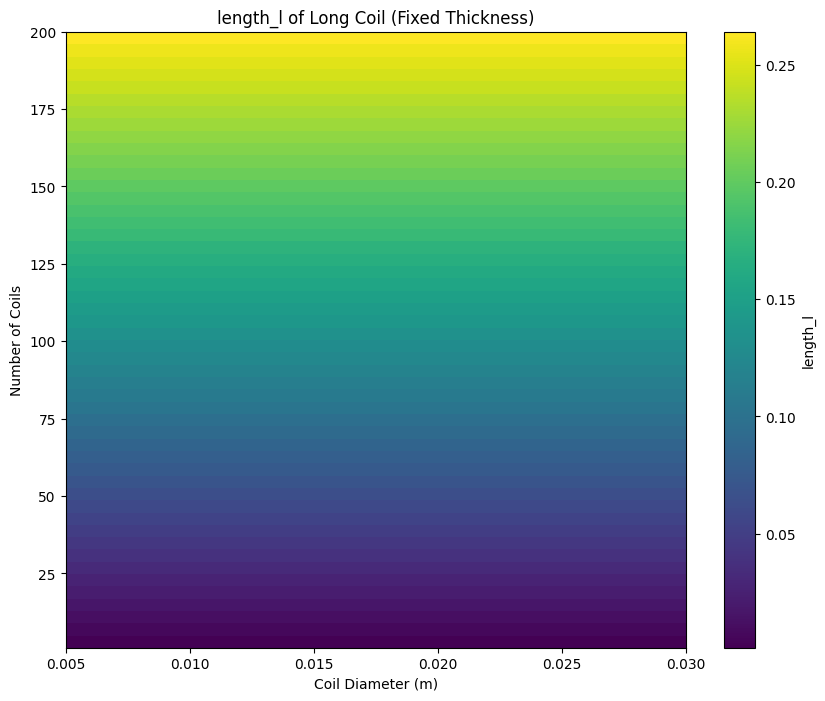

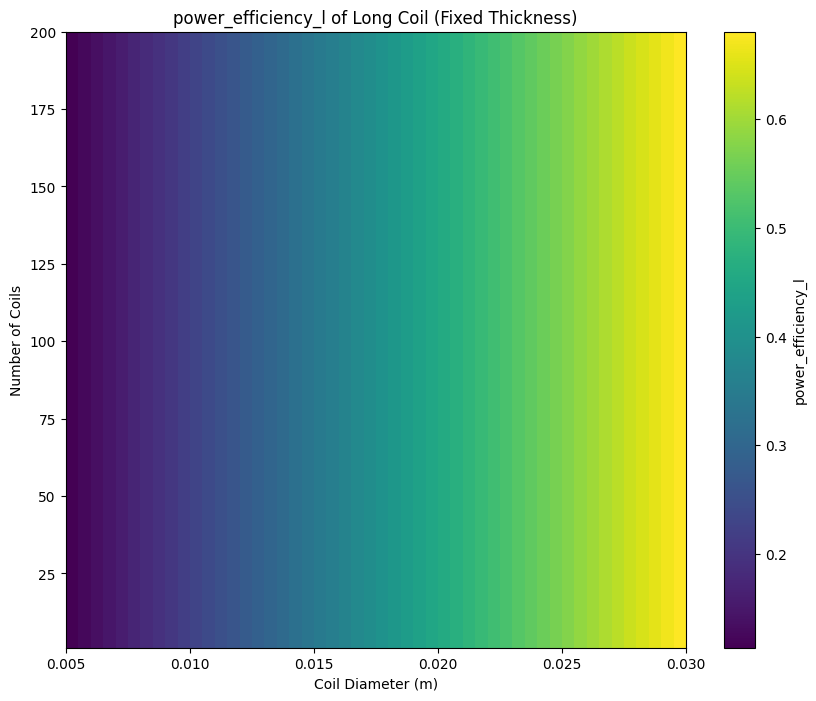

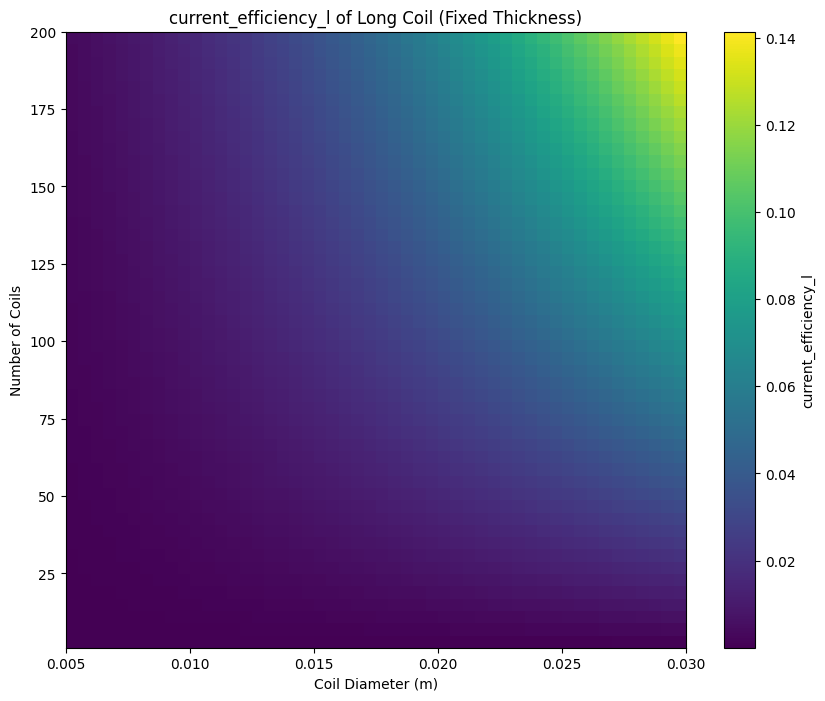

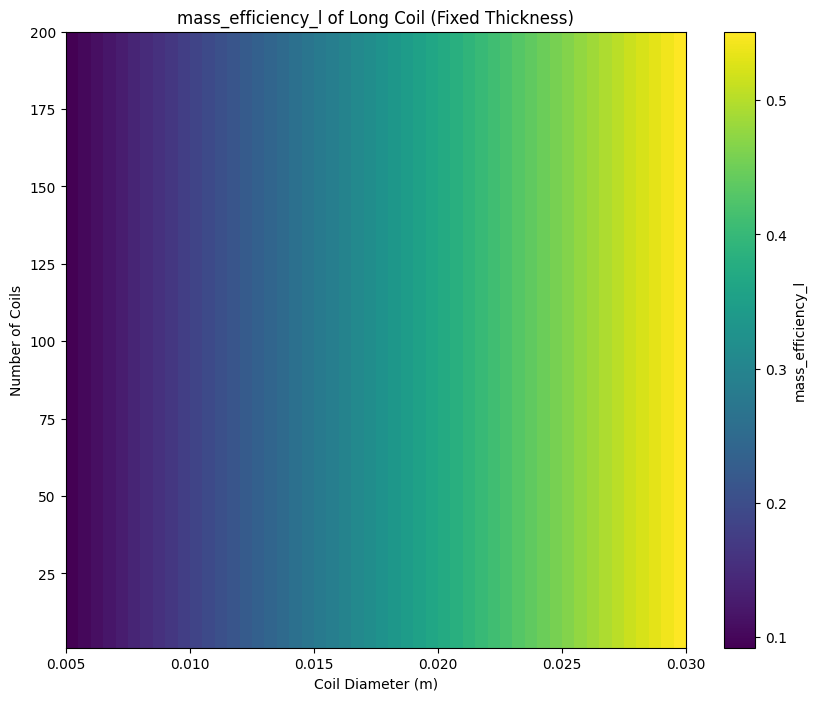

In [ ]:
# Analysis for a single long coil with fixed thickness
num_coils_long_analysis = np.linspace(1, 200, dtype=int, num=50)
diameter_long_analysis = np.linspace(0.005, 0.03, num=50)
fixed_thickness = 0.00132105  # this appeared in the other analysis

# Initialize dictionaries to store results
results = {
    'magnetic_moment_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'resistance_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'power_consumption_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'mass_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'volume_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'length_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'power_efficiency_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'current_efficiency_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis))),
    'mass_efficiency_l': np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis)))
}

for i, n_l in enumerate(num_coils_long_analysis):
    for j, d_l in enumerate(diameter_long_analysis):
        # Calculate parameters for the long coil
        area_l, wire_length_l = circular(d_l, n_l)
        # Calculate coil properties using the coil function
        magnetic_moment_l, resistance_l, power_consumption_l, mass_l, volume_l, length_l, power_efficiency_l, current_efficiency_l, mass_efficiency_l = coil(area_l, wire_length_l, n_l, fixed_thickness, current, resistivity, density)

        # Store results in the dictionary
        results['magnetic_moment_l'][i, j] = magnetic_moment_l
        results['resistance_l'][i, j] = resistance_l
        results['power_consumption_l'][i, j] = power_consumption_l
        results['mass_l'][i, j] = mass_l
        results['volume_l'][i, j] = volume_l
        results['length_l'][i, j] = length_l
        results['power_efficiency_l'][i, j] = power_efficiency_l
        results['current_efficiency_l'][i, j] = current_efficiency_l
        results['mass_efficiency_l'][i, j] = mass_efficiency_l

# Create heatmaps for each characteristic
for characteristic, data in results.items():
    plt.figure(figsize=(10, 8))
    plt.imshow(data, origin='lower', aspect='auto',
               extent=[diameter_long_analysis[0], diameter_long_analysis[-1],
                       num_coils_long_analysis[0], num_coils_long_analysis[-1]],
               cmap='viridis')
    plt.colorbar(label=characteristic) # Use characteristic name as label
    plt.xlabel('Coil Diameter (m)')
    plt.ylabel('Number of Coils')
    plt.title(f'{characteristic} of Long Coil (Fixed Thickness)') # Use characteristic name in title
    plt.grid(False)
    plt.show()

In [ ]:
# Normalize results:
normalized = {}
for characteristic, data in results.items():
  normalized[characteristic] = data/np.max(data)

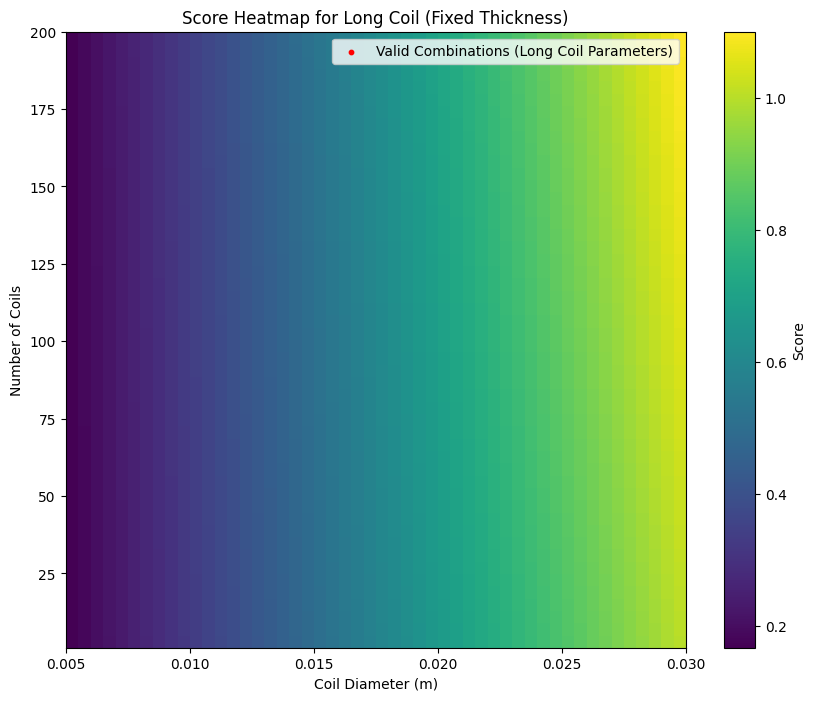

Maximum Score: 1.0999999999999996
Corresponding Number of Coils: 200
Corresponding Diameter: 0.03 m


In [ ]:
def score_function(magnetic_moment, resistance, power_consumption, mass, volume, length, power_efficiency, current_efficiency, mass_efficiency):
  # score = magnetic_moment*1 + power_consumption*-0.5 + mass*-1.0
  score = mass_efficiency + 0.1*magnetic_moment
  return score

# Apply the score function to the normalized results and find the maximum
scores = np.zeros((len(num_coils_long_analysis), len(diameter_long_analysis)))

for i in range(len(num_coils_long_analysis)):
    for j in range(len(diameter_long_analysis)):
        # Get normalized characteristics for the current combination
        normalized_magnetic_moment = normalized['magnetic_moment_l'][i, j]
        normalized_resistance = normalized['resistance_l'][i, j]
        normalized_power_consumption = normalized['power_consumption_l'][i, j]
        normalized_mass = normalized['mass_l'][i, j]
        normalized_volume = normalized['volume_l'][i, j]
        normalized_length = normalized['length_l'][i, j]
        normalized_power_efficiency = normalized['power_efficiency_l'][i, j]
        normalized_current_efficiency = normalized['current_efficiency_l'][i, j]
        normalized_mass_efficiency = normalized['mass_efficiency_l'][i, j]

        # Calculate the score using the score function
        scores[i, j] = score_function(normalized_magnetic_moment, normalized_resistance,
                                      normalized_power_consumption, normalized_mass,
                                      normalized_volume, normalized_length,
                                      normalized_power_efficiency, normalized_current_efficiency,
                                      normalized_mass_efficiency)

# Create a heatmap for the scores
plt.figure(figsize=(10, 8))
plt.imshow(scores, origin='lower', aspect='auto',
           extent=[diameter_long_analysis[0], diameter_long_analysis[-1],
                   num_coils_long_analysis[0], num_coils_long_analysis[-1]],
           cmap='viridis')
plt.colorbar(label='Score')
plt.xlabel('Coil Diameter (m)')
plt.ylabel('Number of Coils')
plt.title('Score Heatmap for Long Coil (Fixed Thickness)')
plt.grid(False)

# Filter working_combos by fixed_thickness with tolerance
tolerance = 1e-5  # Define a suitable tolerance
filtered_working_combos = [combo for combo in working_combos if abs(combo[4] - fixed_thickness) < tolerance]


# Extract the num_coils_long and diameter_long from the filtered_working_combos
valid_num_coils_long = [combo[2] for combo in filtered_working_combos]
valid_diameter_long = [combo[3] for combo in filtered_working_combos]


# Plot the valid combinations on the heatmap
plt.scatter(valid_diameter_long, valid_num_coils_long, color='red', marker='o', s=10, label='Valid Combinations (Long Coil Parameters)')
plt.legend()
plt.show()

# Find the maximum score and its index
max_score_index = np.unravel_index(np.argmax(scores), scores.shape)
max_score = scores[max_score_index]

# Get the corresponding num_coils and diameter
best_num_coils = num_coils_long_analysis[max_score_index[0]]
best_diameter = diameter_long_analysis[max_score_index[1]]

print(f"Maximum Score: {max_score}")
print(f"Corresponding Number of Coils: {best_num_coils}")
print(f"Corresponding Diameter: {best_diameter} m")



In [ ]:
# Calculate and store combined scores for all working_combos
total_scores = []
combo_parameters = []

# Initialize variables to track maximum values for normalization
max_magnetic_moment_l = 0
max_resistance_l = 0
max_power_consumption_l = 0
max_mass_l = 0
max_volume_l = 0
max_length_l = 0
max_power_efficiency_l = 0
max_current_efficiency_l = 0
max_mass_efficiency_l = 0

max_magnetic_moment_f = 0
max_resistance_f = 0
max_power_consumption_f = 0
max_mass_f = 0
max_volume_f = 0
max_length_f = 0
max_power_efficiency_f = 0
max_current_efficiency_f = 0
max_mass_efficiency_f = 0


for combo in working_combos:
    n_f, d_f, n_l, d_l, t = combo

    # Calculate characteristics for the long coil
    area_l, wire_length_l = circular(d_l, n_l)
    magnetic_moment_l, resistance_l, power_consumption_l, mass_l, volume_l, length_l, power_efficiency_l, current_efficiency_l, mass_efficiency_l = coil(area_l, wire_length_l, n_l, t, current, resistivity, density)

    # Update max values for long coil
    max_magnetic_moment_l = max(max_magnetic_moment_l, magnetic_moment_l)
    max_resistance_l = max(max_resistance_l, resistance_l)
    max_power_consumption_l = max(max_power_consumption_l, power_consumption_l)
    max_mass_l = max(max_mass_l, mass_l)
    max_volume_l = max(max_volume_l, volume_l)
    max_length_l = max(max_length_l, length_l)
    max_power_efficiency_l = max(max_power_efficiency_l, power_efficiency_l)
    max_current_efficiency_l = max(max_current_efficiency_l, current_efficiency_l)
    max_mass_efficiency_l = max(max_mass_efficiency_l, mass_efficiency_l)


    # Calculate characteristics for the flat coil
    area_f, wire_length_f = square(d_f, n_f)
    magnetic_moment_f, resistance_f, power_consumption_f, mass_f, volume_f, length_f, power_efficiency_f, current_efficiency_f, mass_efficiency_f = coil(area_f, wire_length_f, n_f, t, current, resistivity, density)

    # Update max values for flat coil
    max_magnetic_moment_f = max(max_magnetic_moment_f, magnetic_moment_f)
    max_resistance_f = max(max_resistance_f, resistance_f)
    max_power_consumption_f = max(max_power_consumption_f, power_consumption_f)
    max_mass_f = max(max_mass_f, mass_f)
    max_volume_f = max(max_volume_f, volume_f)
    max_length_f = max(max_length_f, length_f)
    max_power_efficiency_f = max(max_power_efficiency_f, power_efficiency_f)
    max_current_efficiency_f = max(max_current_efficiency_f, current_efficiency_f)
    max_mass_efficiency_f = max(max_mass_efficiency_f, mass_efficiency_f)

# Now, iterate through the working_combos again to calculate scores using the found max values for normalization
for combo in working_combos:

    n_f, d_f, n_l, d_l, t = combo

    # Calculate characteristics for the long coil
    area_l, wire_length_l = circular(d_l, n_l)
    magnetic_moment_l, resistance_l, power_consumption_l, mass_l, volume_l, length_l, power_efficiency_l, current_efficiency_l, mass_efficiency_l = coil(area_l, wire_length_l, n_l, t, current, resistivity, density)
    # Calculate characteristics for the flat coil
    area_f, wire_length_f = square(d_f, n_f)
    magnetic_moment_f, resistance_f, power_consumption_f, mass_f, volume_f, length_f, power_efficiency_f, current_efficiency_f, mass_efficiency_f = coil(area_f, wire_length_f, n_f, t, current, resistivity, density)


    score_long = score_function(
        magnetic_moment_l / max_magnetic_moment_l if max_magnetic_moment_l != 0 else 0,
        resistance_l / max_resistance_l if max_resistance_l != 0 else 0,
        power_consumption_l / max_power_consumption_l if max_power_consumption_l != 0 else 0,
        mass_l / max_mass_l if max_mass_l != 0 else 0,
        volume_l / max_volume_l if max_volume_l != 0 else 0,
        length_l / max_length_l if max_length_l != 0 else 0,
        power_efficiency_l / max_power_efficiency_l if max_power_efficiency_l != 0 else 0,
        current_efficiency_l / max_current_efficiency_l if max_current_efficiency_l != 0 else 0,
        mass_efficiency_l / max_mass_efficiency_l if max_mass_efficiency_l != 0 else 0
    )

    score_flat = score_function(
        magnetic_moment_f / max_magnetic_moment_f if max_magnetic_moment_f != 0 else 0,
        resistance_f / max_resistance_f if max_resistance_f != 0 else 0,
        power_consumption_f / max_power_consumption_f if max_power_consumption_f != 0 else 0,
        mass_f / max_mass_f if max_mass_f != 0 else 0,
        volume_f / max_volume_f if max_volume_f != 0 else 0,
        length_f / max_length_f if max_length_f != 0 else 0,
        power_efficiency_f / max_power_efficiency_f if max_power_efficiency_f != 0 else 0,
        current_efficiency_f / max_current_efficiency_f if max_current_efficiency_f != 0 else 0,
        mass_efficiency_f / max_mass_efficiency_f if max_mass_efficiency_f != 0 else 0
    )


    # Combine scores
    total_score = 2 * score_long + score_flat

    total_scores.append(total_score)
    combo_parameters.append(combo)

# Find the index of the maximum total score
if total_scores:
    max_total_score_index = np.argmax(total_scores)
    best_total_score = total_scores[max_total_score_index]
    best_combo_params = combo_parameters[max_total_score_index]

    print(f"Maximum Total Score among all Working Combinations: {best_total_score}")
    # print(f"Parameters for the Best Working Combination: {best_combo_params}")
    print("Parameters for best working combination:")
    for param, val in zip(["Number of coils in flat", "Diameter of flat coils (m)", "Number of coils in long", "Diameter of long coils (m)", "Wire thickness (m)"], best_combo_params):
      print(f"{param}: {val}")
else:
    print("No working combinations found.")
    n_f, d_f, n_l, d_l, t

print("")
magnetic_moment, resistance, power_consumption, mass, volume, length, power_efficiency, current_efficiency, mass_efficiency = coil(*circular(d_l, n_l), n_l, t, current, resistivity, density)

print(f"Magnetic Moment: {magnetic_moment} Am^2")
print(f"Resistance: {resistance} Ohm")
print(f"Power Consumption: {power_consumption} W")
print(f"Mass: {mass} kg")
print(f"Volume: {volume} m^3")
print(f"Length: {length} m")
print(f"Power Efficiency: {power_efficiency} Am^2/W")
print(f"Current Efficiency: {current_efficiency} Am^2/A")
print(f"Mass Efficiency: {mass_efficiency} Am^2/kg")


Maximum Total Score among all Working Combinations: 3.199
Parameters for best working combination:
Number of coils in flat: 47
Diameter of flat coils (m): 0.09
Number of coils in long: 105
Diameter of long coils (m): 0.03
Wire thickness (m): 0.0002526315789473684

Magnetic Moment: 0.12723450247038662 Am^2
Resistance: 2.452047900151796 Ohm
Power Consumption: 1.986158799122955 W
Mass: 0.021725001230792882 kg
Volume: 5.729272918257175e-05 m^3
Length: 0.08105263157894736 m
Power Efficiency: 0.06406058897534811 Am^2/W
Current Efficiency: 0.1413716694115407 Am^2/A
Mass Efficiency: 5.856593567877235 Am^2/kg
